In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
data = pd.read_csv("cleaned_data.csv")

The goal for this week with data exploration is to analyze feature distributions, examine feature-feature relationships, use correlation matrices and heatmaps, and explore high-dimensional structure. I think this will be interesting to do with my raw data because it does not include sentiment scores or yFinance data on the change in stock price so the list of features is currently the headline, url, publisher, published date, ticker, and the headline class column I added. Most of the data is categorical so I will do what I can with the raw data.

<function matplotlib.pyplot.show(close=None, block=None)>

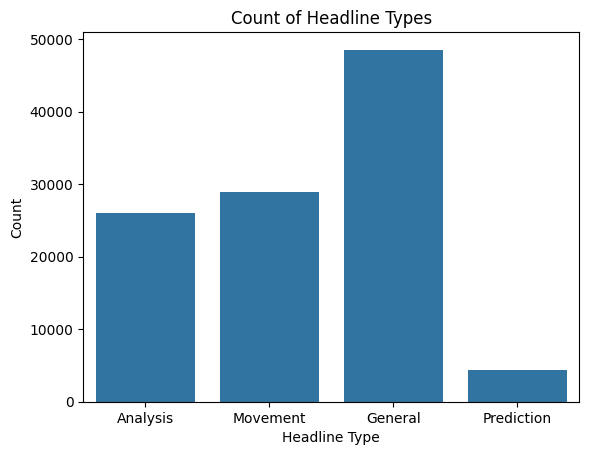

In [9]:
sns.countplot(data=data, x="Headline_Class")
plt.title("Count of Headline Types")
plt.xlabel("Headline Type")
plt.ylabel("Count")
plt.show

The first plot above is a histogram of the custom class I made. We talked about in class how when I eventually get to making this model I do not want to flood the model with articles that are simply just stating the stock price for the day or news that is not trivial that would hamper the models ability to classify a publisher based on actual reporting. For the purposes of training, I am going to focus on prediction and analysis articles because these categories are where the publisher is actually trying to say something about a ticker which is exactly what we want for classifying their abilities.

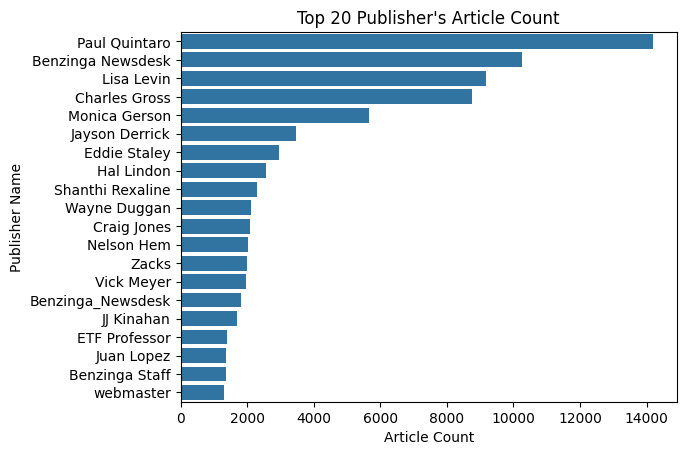

In [8]:
prominent_publishers = data["publisher"].value_counts().head(20)
publisher_count = prominent_publishers.values
publisher_name = prominent_publishers.index
sns.barplot(x=publisher_count, y=publisher_name)
plt.title("Top 20 Publisher's Article Count")
plt.xlabel("Article Count")
plt.ylabel("Publisher Name")
plt.show()

The figure above shows the top 20 publishers in terms of amount of articles written in the data set. This may be important later for my classification model because I will need to set a sample size limit to even consider an author for classification which actually makes me curious what the fewest articles publisher are. 

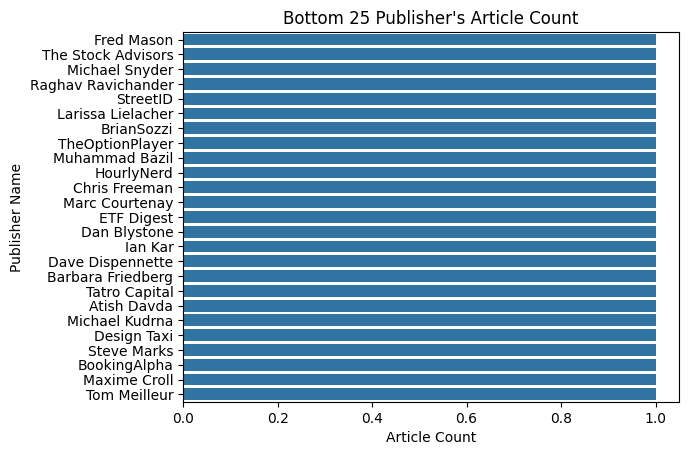

In [12]:
small_publishers = data["publisher"].value_counts().tail(25)
publisher_count = small_publishers.values
publisher_name = small_publishers.index
sns.barplot(x=publisher_count, y=publisher_name)
plt.title("Bottom 25 Publisher's Article Count")
plt.xlabel("Article Count")
plt.ylabel("Publisher Name")
plt.show()

The figure above is an issue because its not possible to classify authors based on a sample of 1 article they wrote so I would like to discuss this in class and determine a valid sample size.

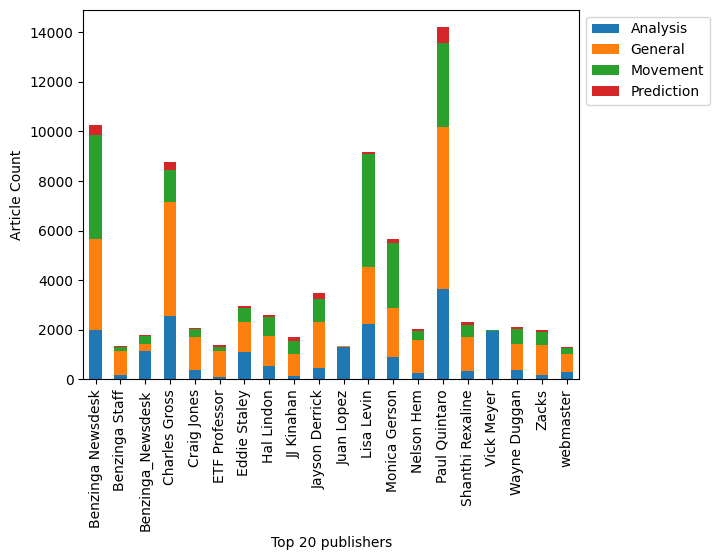

In [25]:
# https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.crosstab.html
top_publishers = data['publisher'].value_counts().head(20).index
filtered_publishers = data[data['publisher'].isin(top_publishers)] # Get only the data that is the top 20 publishers
plot_data = pd.crosstab(filtered_publishers['publisher'], filtered_publishers['Headline_Class'])
plot_data.plot(kind="bar", stacked=True)
plt.xlabel("Top 20 publishers")
plt.ylabel("Article Count")
plt.legend(bbox_to_anchor=(1, 1), loc="upper left")


The plot above shows the distibution of article type by the top 20 publishers. Based on the raw counts this is expected with general and movement dominating the article type while analysis and prediction take on a much smaller subset. Two interesting anomalies are Benzinga Newsdesk and Lisa Levin reporting more movement than general articles suggesting they post often about what is happening to the price of tickers themselves rather than things that may be impacting the price. 

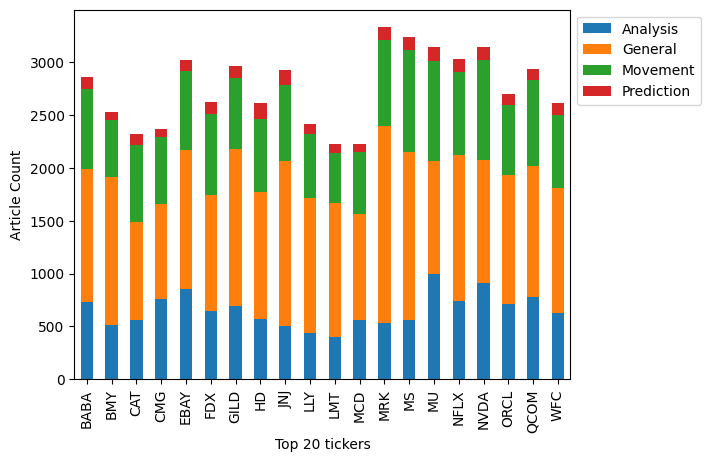

In [24]:
top_tickers = data['ticker'].value_counts().head(20).index
filtered_ticker = data[data['ticker'].isin(top_tickers)] # Get only the data that is the top 20 tickers
plot_data = pd.crosstab(filtered_ticker['ticker'], filtered_ticker['Headline_Class'])
plot_data.plot(kind="bar", stacked=True)
plt.xlabel("Top 20 tickers")
plt.ylabel("Article Count")
plt.legend(bbox_to_anchor=(1, 1), loc="upper left")